In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('black_friday_sales.csv')

In [3]:
df = data.copy()

In [4]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [5]:
df.shape

(550068, 12)

### Data Cleaning and Assesment

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


<Axes: >

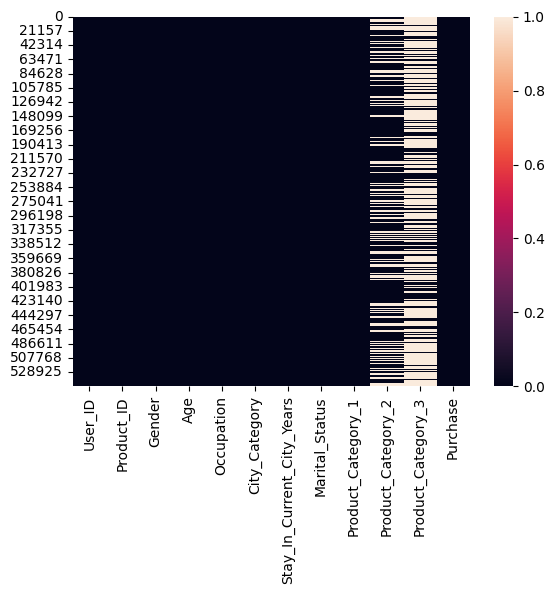

In [8]:
sns.heatmap(df.isnull())

In [9]:
df.isna().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,173638


In [10]:
# rename columns

In [11]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

In [12]:
df.rename(columns = {
  'User_ID' : 'user_id',
  'Product_ID': 'product_id',
  'Gender': 'gender',
  'Age': 'age',
  'Occupation': 'occupation',
  'City_Category': 'city_category',
  'Stay_In_Current_City_Years' : 'years_in_city',
  'Marital_Status': 'marital_status',
  'Product_Category_1': 'prod_cat_1',
  'Product_Category_2': 'prod_cat_2',
  'Product_Category_3': 'prod_cat_3',
  'Purchase': 'purchases'
  }, inplace=True)

In [13]:
df.columns

Index(['user_id', 'product_id', 'gender', 'age', 'occupation', 'city_category',
       'years_in_city', 'marital_status', 'prod_cat_1', 'prod_cat_2',
       'prod_cat_3', 'purchases'],
      dtype='object')

In [26]:
# check duplicates

df.duplicated().sum()

np.int64(0)

##Assessing column one by one

In [14]:
# user_id

In [27]:
df['user_id'].unique().shape

(5891,)

In [28]:
# product_id

In [30]:
df['product_id'].unique().shape

(3631,)

In [31]:
# gender

In [35]:
df['gender'].unique()


array(['F', 'M'], dtype=object)

In [36]:
# age

In [37]:
df['age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [44]:
def ages(value):
  if value == '0-17':
    value= value.replace('0-17', 'child')
    return str(value)
  elif value == '18-25':
    value= value.replace('18-25', 'tenage')
    return str(value)
  elif value == '26-35':
    value= value.replace('26-35', 'adult (26-35)')
    return str(value)
  elif value == '36-45':
    value= value.replace('36-45', 'adult (36-45)')
    return str(value)
  elif value == '46-50':
    value= value.replace('46-50', 'adult (46-50)')
    return str(value)
  elif value == '51-55':
    value= value.replace('51-55', 'old (51-55)')
    return str(value)
  elif value == '55+':
    value= value.replace('55+', 'old')
    return str(value)

df['age'] = df['age'].apply(ages)


In [47]:
df['age'].unique()

array(['child', 'old', 'adult (26-35)', 'adult (46-50)', 'old (51-55)',
       'adult (36-45)', 'tenage'], dtype=object)

In [48]:
# ocupation

In [51]:
df['occupation'].unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

In [52]:
#city category

In [53]:
df['city_category'].unique()

array(['A', 'C', 'B'], dtype=object)

In [54]:
df['years_in_city'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [55]:
# marital status

In [58]:
df['marital_status'] = df['marital_status'].replace({0: 'single', 1:'married'})

In [59]:
# prod_cat_1, prod_cat_2, prod_cat_3

In [64]:
np.sort(df['prod_cat_1'].unique())

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [65]:
np.sort(df['prod_cat_2'].unique())

array([ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14.,
       15., 16., 17., 18., nan])

In [70]:
df[df['prod_cat_2'].isna()]['prod_cat_3'].value_counts()

,count
prod_cat_3,


In [72]:
df[df['prod_cat_3'].isna()]['prod_cat_2'].value_counts()

,count
prod_cat_2,
14.0,43103
16.0,42372
8.0,37141
15.0,23361
17.0,13320
5.0,10400
11.0,8340
4.0,6123
2.0,5683


- missing values in prod_cat_2 and prod_cat_3 suggest that the categories are heirerical.

In [90]:
df.groupby('prod_cat_1')['prod_cat_2'].apply(lambda x: x.isnull().mean()).sort_values()

,prod_cat_2
prod_cat_1,
9,0.002439
3,0.011824
4,0.012167
2,0.038971
1,0.047002
6,0.048519
10,0.088976
13,0.112813
5,0.422042


- prod_cat_1 > 15 has no categporisation

In [91]:
df.groupby('prod_cat_2')['prod_cat_3'].apply(lambda x: x.isnull().mean()).sort_values()

,prod_cat_3
prod_cat_2,
3.0,0.000000
2.0,0.115468
4.0,0.238462
10.0,0.256983
6.0,0.262905
5.0,0.396417
13.0,0.418764
9.0,0.475672
8.0,0.579531


- we will replace null values in prod_category columns with None

In [95]:
df['prod_cat_2'].fillna('None', inplace=True)

/tmp/ipython-input-3439853297.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['prod_cat_2'].fillna('None', inplace=True)


In [96]:
df['prod_cat_2'].isna().sum()

np.int64(0)

In [100]:
df['prod_cat_3'].fillna('None', inplace=True)

/tmp/ipython-input-419664493.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['prod_cat_3'].fillna('None', inplace=True)
/tmp/ipython-input-419664493.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['prod_cat_3'].fillna('None', inplace=True)


In [101]:
df.head()

,user_id,product_id,gender,age,occupation,city_category,years_in_city,marital_status,prod_cat_1,prod_cat_2,prod_cat_3,purchases
0,1000001,P00069042,F,child,10,A,2,single,3,None,None,8370
1,1000001,P00248942,F,child,10,A,2,single,1,6.0,14.0,15200
2,1000001,P00087842,F,child,10,A,2,single,12,None,None,1422
3,1000001,P00085442,F,child,10,A,2,single,12,14.0,None,1057
4,1000002,P00285442,M,old,16,C,4+,single,8,None,None,7969


In [102]:
# purchases

In [104]:
df['purchases']

,purchases
0,8370
1,15200
2,1422
3,1057
4,7969
...,...
550063,368
550064,371
550065,137
550066,365


## EDA - Univariate analysis

In [110]:
df.sample(10)

,user_id,product_id,gender,age,occupation,city_category,years_in_city,marital_status,prod_cat_1,prod_cat_2,prod_cat_3,purchases
409177,1003003,P00127642,M,tenage,15,B,3,single,1,2.0,15.0,15166
153300,1005688,P00178242,F,tenage,4,B,1,single,8,None,None,7940
422705,1005049,P00370642,M,adult (26-35),12,B,0,single,8,16.0,None,7860
533496,1004115,P00227542,M,adult (26-35),15,B,1,single,13,None,None,758
18691,1002934,P00315842,F,adult (36-45),20,B,3,single,5,None,None,6931
243608,1001546,P00059442,M,adult (26-35),4,A,4+,married,6,8.0,16.0,16268
339729,1004277,P00048742,M,adult (36-45),16,A,0,single,5,None,None,6952
320411,1001354,P00343042,F,adult (26-35),2,B,3,single,5,18.0,None,7188
379968,1004438,P00271042,M,old (51-55),0,C,2,single,6,16.0,None,15947
27869,1004269,P0096442,M,adult (36-45),18,B,1,married,4,5.0,12.0,2779


In [109]:
df.columns

Index(['user_id', 'product_id', 'gender', 'age', 'occupation', 'city_category',
       'years_in_city', 'marital_status', 'prod_cat_1', 'prod_cat_2',
       'prod_cat_3', 'purchases'],
      dtype='object')

/tmp/ipython-input-1059935926.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x=f'{col}', palette='viridis', ax=axes[0])


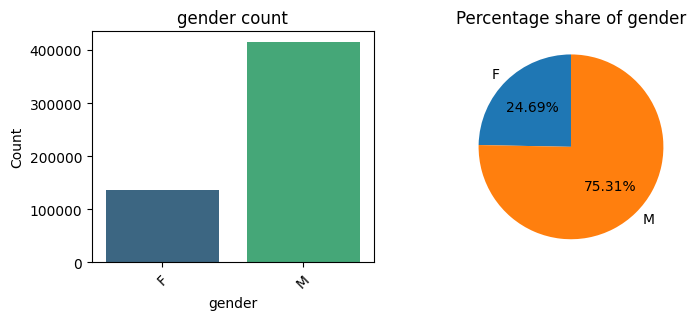

/tmp/ipython-input-1059935926.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x=f'{col}', palette='viridis', ax=axes[0])


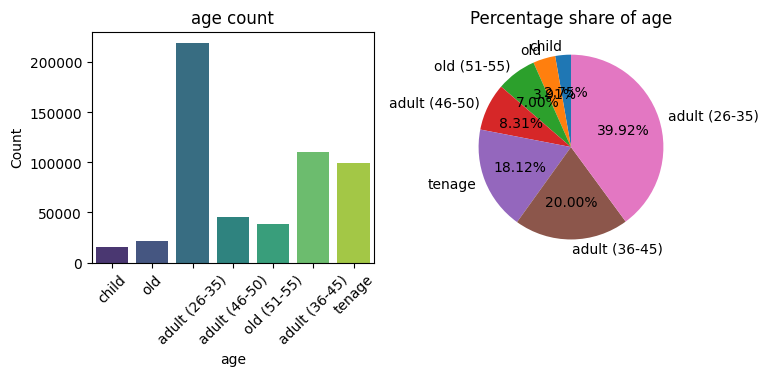

/tmp/ipython-input-1059935926.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x=f'{col}', palette='viridis', ax=axes[0])


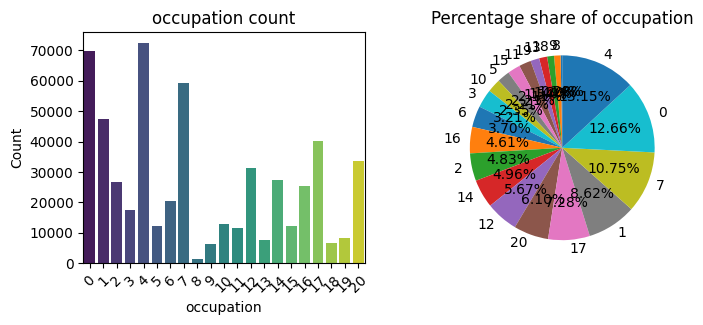

/tmp/ipython-input-1059935926.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x=f'{col}', palette='viridis', ax=axes[0])


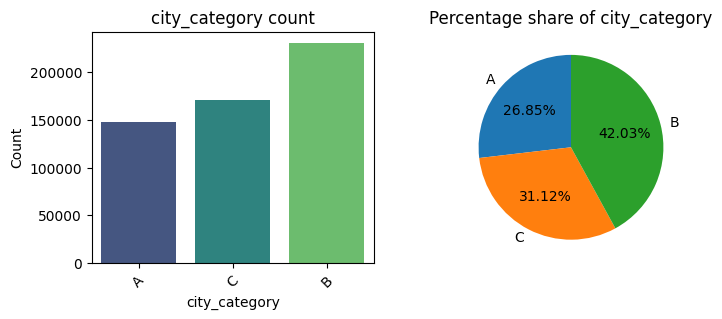

/tmp/ipython-input-1059935926.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x=f'{col}', palette='viridis', ax=axes[0])


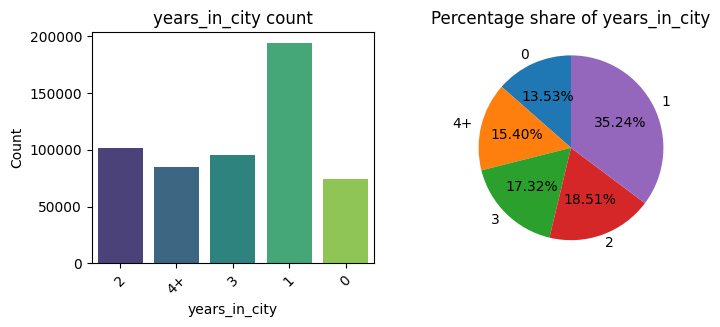

/tmp/ipython-input-1059935926.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x=f'{col}', palette='viridis', ax=axes[0])


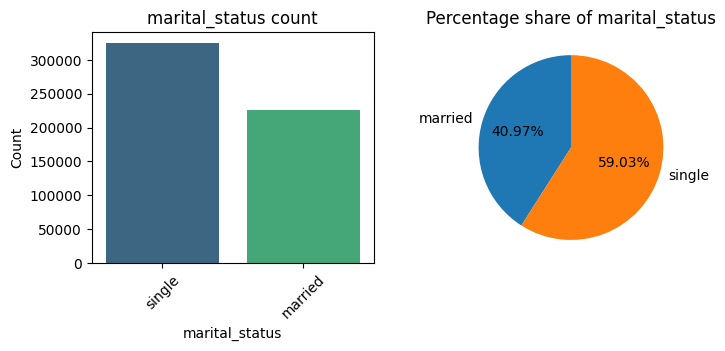

In [144]:
cat_col = ['gender', 'age', 'occupation', 'city_category', 'years_in_city', 'marital_status']

for col in cat_col:
  fig, axes = plt.subplots(1, 2, figsize=(8, 3))

  sns.countplot(data= df, x=f'{col}', palette='viridis', ax=axes[0])
  axes[0].tick_params(axis='x', rotation=45)
  axes[0].set_title(f'{col} count')
  axes[0].set_ylabel('Count')

  df[col].value_counts().sort_values().plot(kind='pie', autopct='%0.2f%%', ax=axes[1], startangle=90)
  axes[1].set_title(f'Percentage share of {col}')
  axes[1].set_ylabel('')

  plt.show()

- male count very high in comparision to females
- most buyers are adult between 26-35 age group
- ocupation category 0, 4, 7 are the most common
- highest number of people live in city B and most people have lived there for about 1 year
- highest number of purchasers are single.

In [147]:
# prod_cat_1

/tmp/ipython-input-2518291061.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x='prod_cat_1', kind='count', palette='viridis')


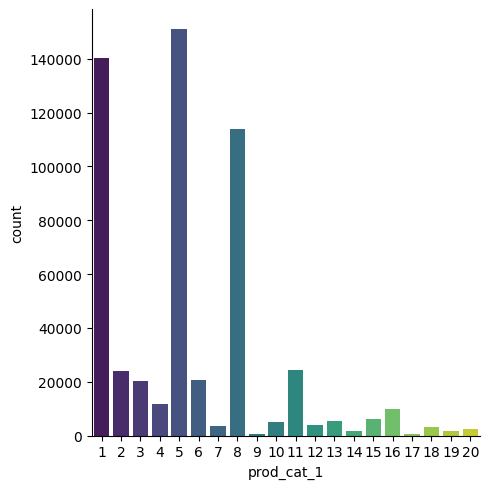

In [146]:
sns.catplot(data=df, x='prod_cat_1', kind='count', palette='viridis')

- 1, 5, 8 prod_cat_1 are the most popular
- 17 and 9 prod_cat_1 are least popular

In [148]:
# puchases

In [150]:
df['purchases'].describe()

,purchases
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


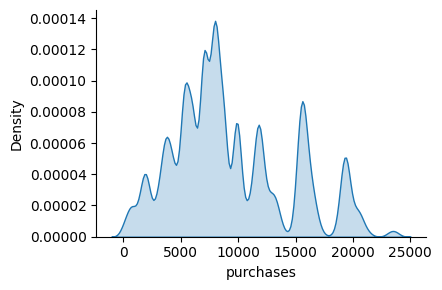

In [158]:
sns.displot(data=df, x= 'purchases', kind='kde', fill=True, height=3, aspect=1.5)

<Axes: ylabel='Frequency'>

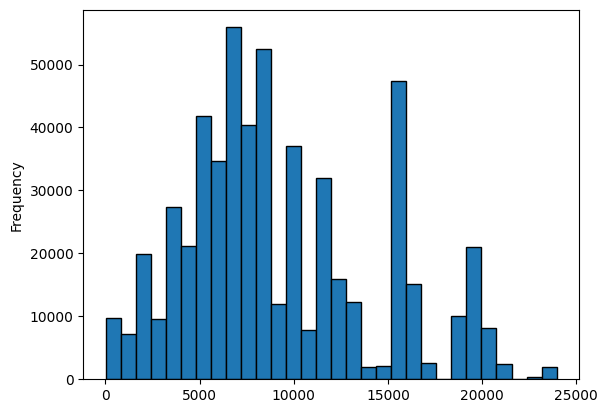

In [164]:
df['purchases'].plot(kind='hist', edgecolor='black', bins=30)

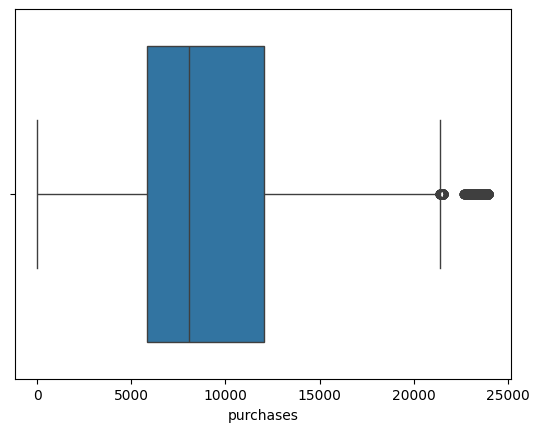

<Axes: xlabel='purchases'>

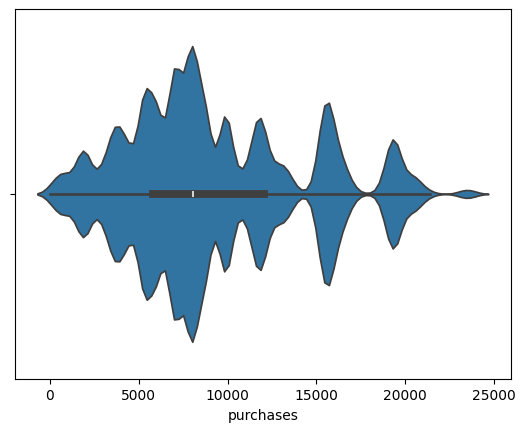

In [170]:
sns.boxplot(data=df, x='purchases')
plt.show()
sns.violinplot(data=df, x='purchases')

### EDA - Bi variate and Multivariate analysis

In [171]:
df.head()

,user_id,product_id,gender,age,occupation,city_category,years_in_city,marital_status,prod_cat_1,prod_cat_2,prod_cat_3,purchases
0,1000001,P00069042,F,child,10,A,2,single,3,None,None,8370
1,1000001,P00248942,F,child,10,A,2,single,1,6.0,14.0,15200
2,1000001,P00087842,F,child,10,A,2,single,12,None,None,1422
3,1000001,P00085442,F,child,10,A,2,single,12,14.0,None,1057
4,1000002,P00285442,M,old,16,C,4+,single,8,None,None,7969


(7000.0, 10000.0)

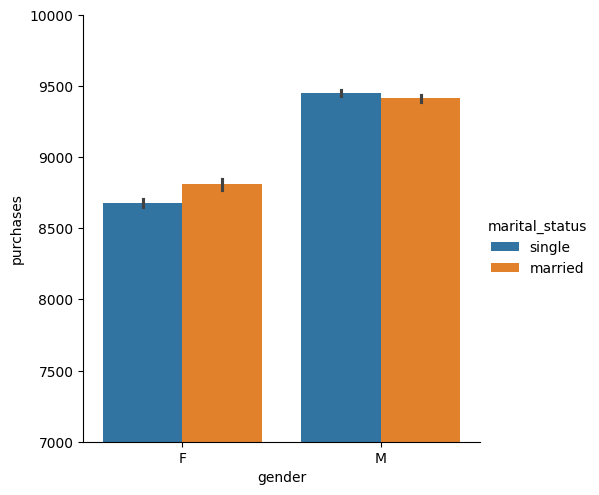

In [180]:
sns.catplot(data=df, x='gender', y='purchases', kind='bar', hue='marital_status',estimator=np.mean)
plt.ylim(7000, 10000)

- males have spent more
- In case of females, the spend is higher in maried females but in case of males single males spend more.

In [181]:
df.columns

Index(['user_id', 'product_id', 'gender', 'age', 'occupation', 'city_category',
       'years_in_city', 'marital_status', 'prod_cat_1', 'prod_cat_2',
       'prod_cat_3', 'purchases'],
      dtype='object')

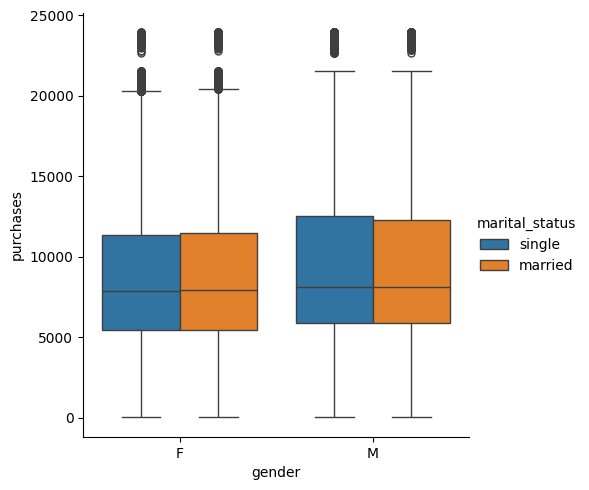

In [182]:
sns.catplot(data=df, x='gender', y='purchases', kind='box', hue='marital_status')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'child'),
  Text(1, 0, 'old'),
  Text(2, 0, 'adult (26-35)'),
  Text(3, 0, 'adult (46-50)'),
  Text(4, 0, 'old (51-55)'),
  Text(5, 0, 'adult (36-45)'),
  Text(6, 0, 'tenage')])

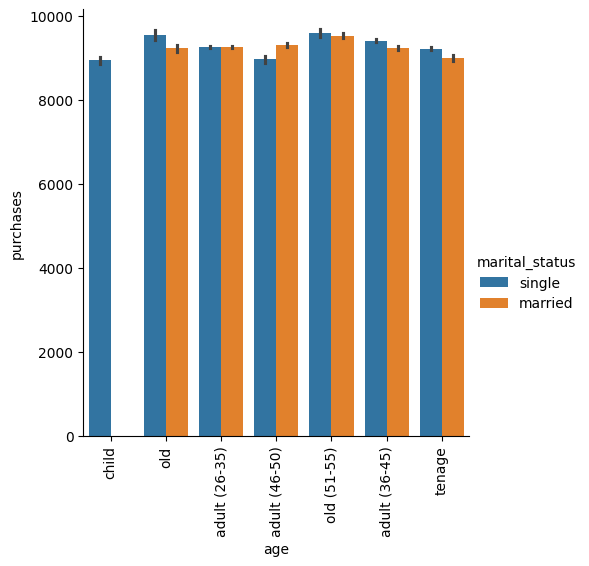

In [195]:
sns.catplot(data=df, x='age', y='purchases', hue='marital_status', kind='bar')
plt.xticks(rotation=90)

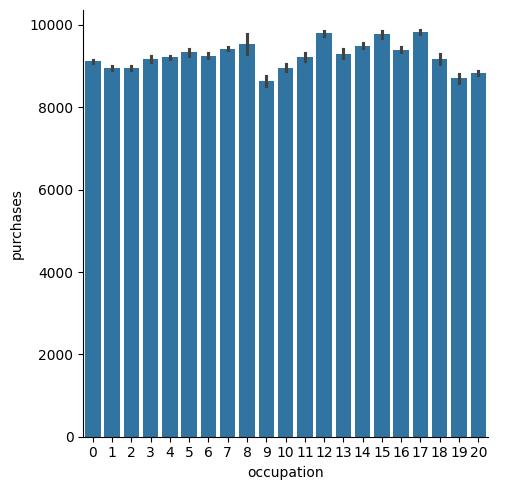

In [200]:
sns.catplot(data=df, x='occupation', y='purchases', kind='bar')

<Axes: xlabel='city_category', ylabel='age'>

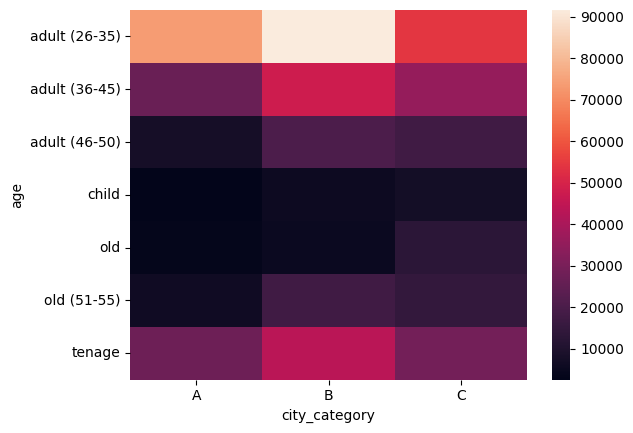

In [205]:
sns.heatmap(pd.crosstab(df['age'], df['city_category']))

In [206]:
df.head()

,user_id,product_id,gender,age,occupation,city_category,years_in_city,marital_status,prod_cat_1,prod_cat_2,prod_cat_3,purchases
0,1000001,P00069042,F,child,10,A,2,single,3,None,None,8370
1,1000001,P00248942,F,child,10,A,2,single,1,6.0,14.0,15200
2,1000001,P00087842,F,child,10,A,2,single,12,None,None,1422
3,1000001,P00085442,F,child,10,A,2,single,12,14.0,None,1057
4,1000002,P00285442,M,old,16,C,4+,single,8,None,None,7969


<Axes: xlabel='years_in_city', ylabel='age'>

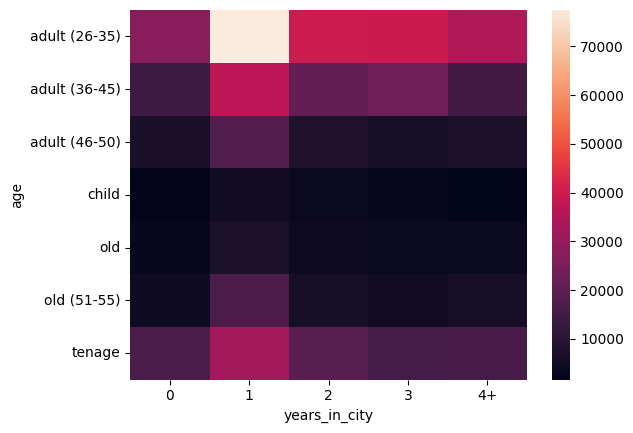

In [212]:
sns.heatmap(pd.crosstab(df['age'], df['years_in_city']))

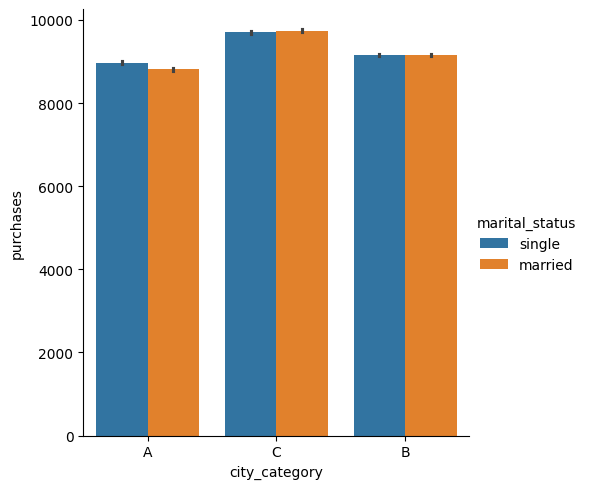

In [209]:
sns.catplot(data=df, x='city_category', y='purchases', kind='bar', hue='marital_status')

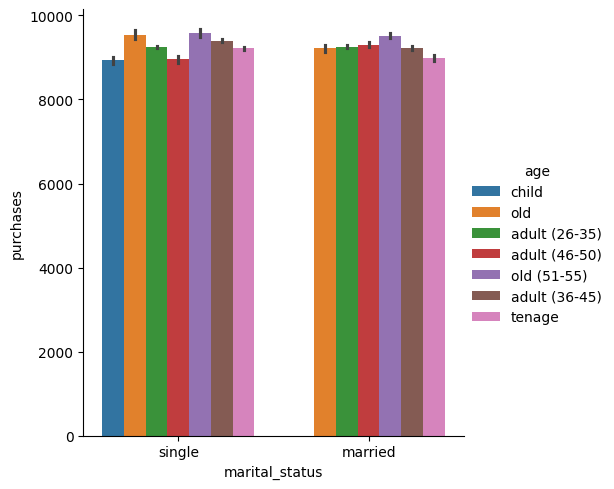

In [213]:
sns.catplot(data=df, x='marital_status', y='purchases', kind='bar', hue='age')

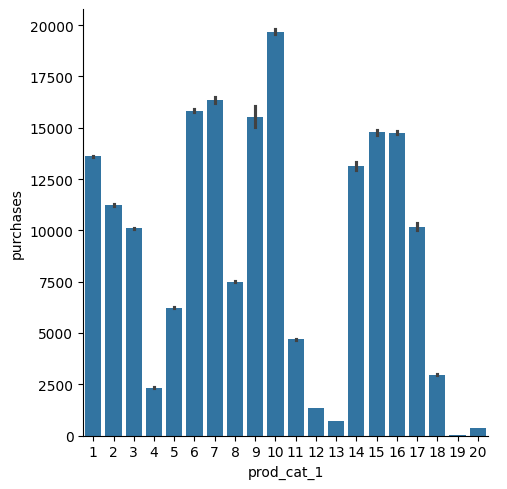

In [223]:
sns.catplot(data=df, x='prod_cat_1', y='purchases', kind='bar', estimator=np.mean)

<Axes: xlabel='prod_cat_1', ylabel='gender'>

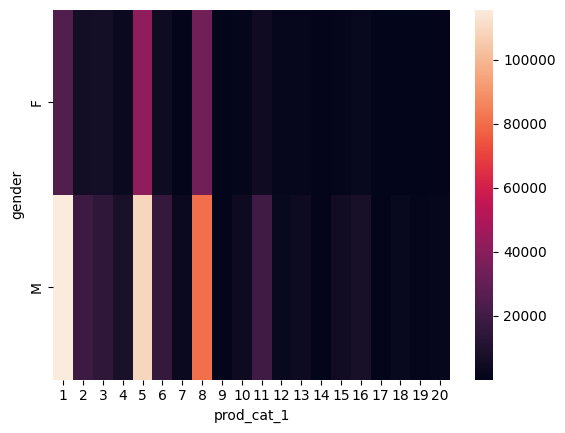

In [222]:
sns.heatmap(pd.crosstab(df['gender'], df['prod_cat_1']))

In [227]:
df.groupby('product_id')['purchases']

,purchases
product_id,
P00370293,36.675159
P00370853,37.393643
P00371644,362.911012
P00375436,374.266585
P00372445,374.930705
...,...
P00119342,20448.756494
P00116142,20463.791277
P00200642,20468.773234
